# CGS 410 - Decoding the Temporal and Topological Fingerprints of Human Language

This notebook is the main execution dashboard.
Core logic lives in `src/parser.py`, `src/generator.py`, and `src/analyzer.py`.


## Step 0: Setup & Imports

In [1]:
import os
import sys
import random
import copy
import time
import pickle
from typing import List, Dict, Tuple, Optional

import networkx as nx
import matplotlib.pyplot as plt
plt.style.use('dark_background')


In [2]:
# Add src/ to Python path so our modules are importable
sys.path.insert(0, os.path.abspath('src'))
from parser import parse_all_conllu_in_dir, MAX_EDGES
from generator import RandomBaselineGenerator, count_crossings, ABSTRACT_ROOT
from analyzer import get_tree_features


## Step 1: Load the Corpus

In [3]:
CORPUS_DIR = r"train"

print("Scanning:", os.path.abspath(CORPUS_DIR), "\n")
corpus = parse_all_conllu_in_dir(CORPUS_DIR)

total_sentences = sum(len(recs) for recs in corpus.values())
print("\nTotal sentences loaded (1 < edges <", MAX_EDGES, "):", total_sentences)


Scanning: c:\Users\tusha\OneDrive\Documents\CGS_Project\train 

[1/10] ✓ Loaded Italian         :  4576 sentences (edges < 12)
[2/10] ✓ Loaded english         :  4982 sentences (edges < 12)
[3/10] ✓ Loaded french          :  2662 sentences (edges < 12)
[4/10] ✓ Loaded hindi           :  2381 sentences (edges < 12)
[5/10] ✓ Loaded japanese        :  1693 sentences (edges < 12)
[6/10] ✓ Loaded korean          :  2766 sentences (edges < 12)
[7/10] ✓ Loaded latin           : 10434 sentences (edges < 12)
[8/10] ✓ Loaded russian         : 30737 sentences (edges < 12)
[9/10] ✓ Loaded spanish         :  2141 sentences (edges < 12)
[10/10] ✓ Loaded turkish         :  5020 sentences (edges < 12)

Total sentences loaded (1 < edges < 12 ): 67392


### 1.1 Quick Statistics

Total sentences : 67392
Min edge count  : 2
Max edge count  : 11
Mean edge count : 6.92

Language                                   Sentences
----------------------------------------------------
Italian                                         4576
english                                         4982
french                                          2662
hindi                                           2381
japanese                                        1693
korean                                          2766
latin                                          10434
russian                                        30737
spanish                                         2141
turkish                                         5020


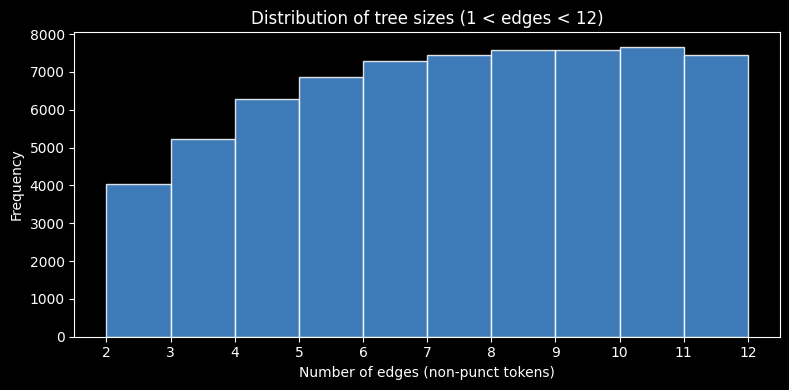

In [4]:
if corpus:
    edge_counts = [rec['n_edges'] for recs in corpus.values() for rec in recs]
    total = len(edge_counts)

    print("Total sentences :", total)
    print("Min edge count  :", min(edge_counts))
    print("Max edge count  :", max(edge_counts))
    print("Mean edge count :", round(sum(edge_counts)/total, 2))

    print()
    print(f"{'Language':<40s}  {'Sentences':>10s}")
    print('-' * 52)
    for lang, recs in corpus.items():
        print(f"{lang:<40s}  {len(recs):>10d}")

    plt.figure(figsize=(8, 4))
    plt.hist(edge_counts, bins=range(2, MAX_EDGES + 1),
             edgecolor='white', color='#4A90D9', alpha=0.85)
    plt.xlabel('Number of edges (non-punct tokens)')
    plt.ylabel('Frequency')
    plt.title('Distribution of tree sizes (1 < edges < ' + str(MAX_EDGES) + ')')
    plt.xticks(range(2, MAX_EDGES + 1))
    plt.tight_layout()
    plt.show()
else:
    print("No trees loaded - check CORPUS_DIR path.")


### 1.2 Visualise a Single Dependency Tree

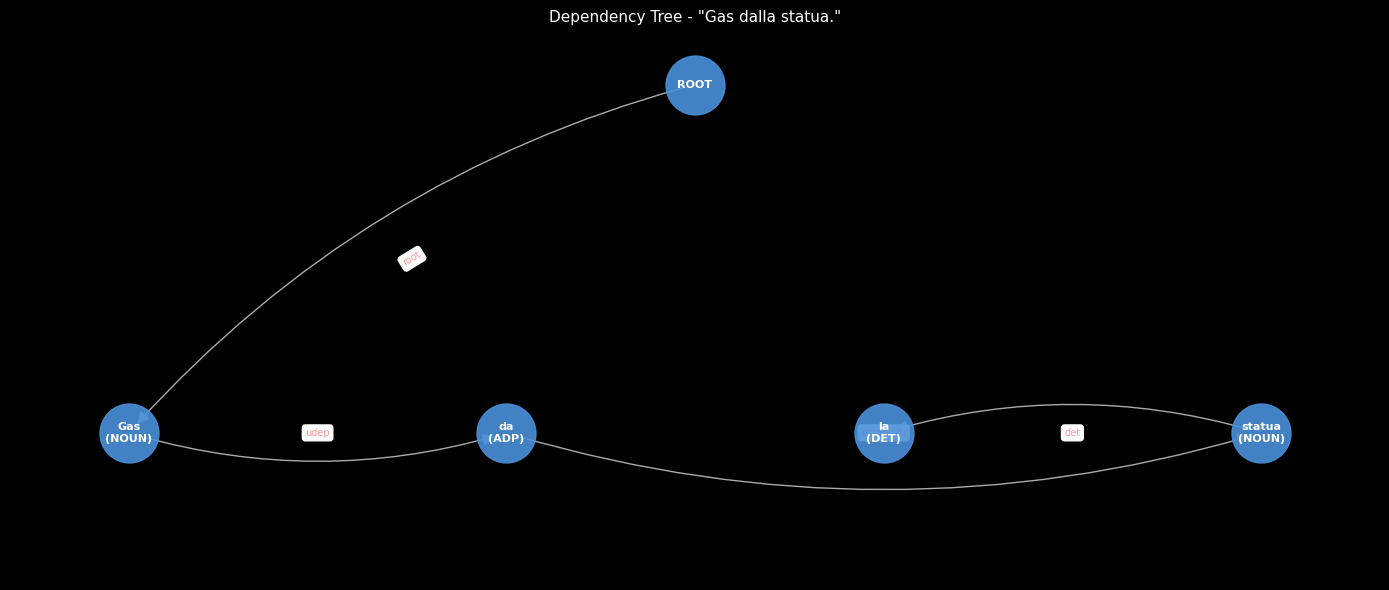

In [5]:
def plot_dependency_tree(rec: Dict, figsize: Tuple = (14, 6)):
    """Draw a dependency tree using NetworkX + Matplotlib."""
    tree = rec['tree']
    non_root_nodes = sorted(n for n in tree.nodes if n != 0)

    pos = {}
    mid = (non_root_nodes[0] + non_root_nodes[-1]) / 2 if non_root_nodes else 0
    pos[0] = (mid, 1)
    for n in non_root_nodes:
        pos[n] = (n, 0)

    labels = {0: 'ROOT'}
    for n in non_root_nodes:
        a = tree.nodes[n]
        labels[n] = str(a.get('form', '?')) + '\n(' + str(a.get('upostag', '?')) + ')'

    edge_labels = {(h, d): data.get('drel', '')
                   for h, d, data in tree.edges(data=True)}

    fig, ax = plt.subplots(figsize=figsize)
    nx.draw_networkx_nodes(tree, pos, node_color='#4A90D9', node_size=1800,
                           alpha=0.9, ax=ax)
    nx.draw_networkx_labels(tree, pos, labels, font_size=8,
                            font_weight='bold', font_color='white', ax=ax)
    nx.draw_networkx_edges(tree, pos, edge_color='#AAAAAA', arrows=True,
                           arrowsize=18, connectionstyle='arc3,rad=0.15', ax=ax)
    nx.draw_networkx_edge_labels(tree, pos, edge_labels, font_size=7,
                                 font_color='#FF9999', ax=ax)
    title = rec.get('text', '')[:80] or 'Sentence ' + str(rec['sent_id'])
    ax.set_title('Dependency Tree - "' + title + '"', fontsize=11, pad=15)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Plot first tree of first loaded language
if corpus:
    first_lang = list(corpus.keys())[0]
    if corpus[first_lang]:
        plot_dependency_tree(corpus[first_lang][0])


## Step 2: Generate Random Baselines

For each real sentence tree we generate a mathematically matching random DAG
that controls for node count and crossing count (DLM-ICM methodology).
Results are cached per-language in `Random_Data/`.


### 2.4 Generate / Load Random Baselines

In [6]:
os.makedirs("Random_Data", exist_ok=True)
corpus_with_baselines = {}
MAX_SENTENCES = 1500

for lang, recs in corpus.items():
    output_file = "Random_Data/Random_Data_" + lang + ".pkl"
    print("\n" + "="*50)
    print("Language:", lang)
    print("="*50)

    if os.path.exists(output_file):
        print("Found existing file:", output_file)
        with open(output_file, 'rb') as f:
            data = pickle.load(f)

        if len(data) > MAX_SENTENCES:
            print("Capping from", len(data), "to", MAX_SENTENCES, "for balance.")
            data = data[:MAX_SENTENCES]

        corpus_with_baselines[lang] = data
        print("Loaded", len(data), "trees.")
        continue

    # Generate fresh
    current_recs = random.sample(recs, min(len(recs), MAX_SENTENCES))
    print("Generating", len(current_recs), "random baselines...")

    success_count, fail_count = 0, 0
    t0 = time.time()

    for i, rec in enumerate(current_recs):
        gen = RandomBaselineGenerator(rec['tree'], real_root=0)
        rand_tree = gen.generate(max_attempts=40000)
        rec['random_tree'] = rand_tree
        rec['num_cross_real'] = gen.num_cross_real

        if rand_tree is not None:
            success_count += 1
        else:
            fail_count += 1

        if (i + 1) % 50 == 0:
            elapsed = round(time.time() - t0, 1)
            print("  [" + str(i+1) + "/" + str(len(current_recs)) + "]",
                  " success=" + str(success_count),
                  " fail=" + str(fail_count),
                  " (" + str(elapsed) + "s)")

    with open(output_file, 'wb') as f:
        pickle.dump(current_recs, f)
    corpus_with_baselines[lang] = current_recs
    print("DONE:", lang, "(" + str(round(time.time()-t0, 1)) + "s)")



Language: Italian
Found existing file: Random_Data/Random_Data_Italian.pkl
Loaded 1500 trees.

Language: english
Found existing file: Random_Data/Random_Data_english.pkl
Capping from 4982 to 1500 for balance.
Loaded 1500 trees.

Language: french
Found existing file: Random_Data/Random_Data_french.pkl
Loaded 1500 trees.

Language: hindi
Found existing file: Random_Data/Random_Data_hindi.pkl
Capping from 2381 to 1500 for balance.
Loaded 1500 trees.

Language: japanese
Found existing file: Random_Data/Random_Data_japanese.pkl
Capping from 1693 to 1500 for balance.
Loaded 1500 trees.

Language: korean
Found existing file: Random_Data/Random_Data_korean.pkl
Capping from 2766 to 1500 for balance.
Loaded 1500 trees.

Language: latin
Found existing file: Random_Data/Random_Data_latin.pkl
Loaded 1500 trees.

Language: russian
Found existing file: Random_Data/Random_Data_russian.pkl
Loaded 1500 trees.

Language: spanish
Found existing file: Random_Data/Random_Data_spanish.pkl
Capping from 2141 

### 2.5 Inspect Real vs. Random Tree Pairs

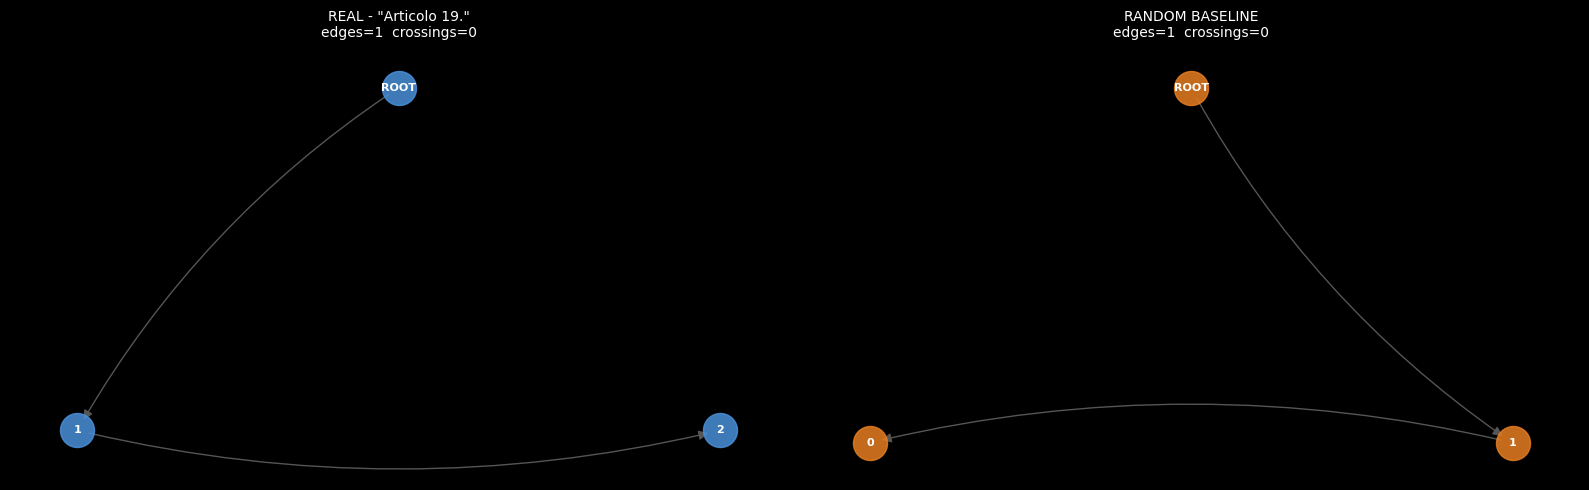

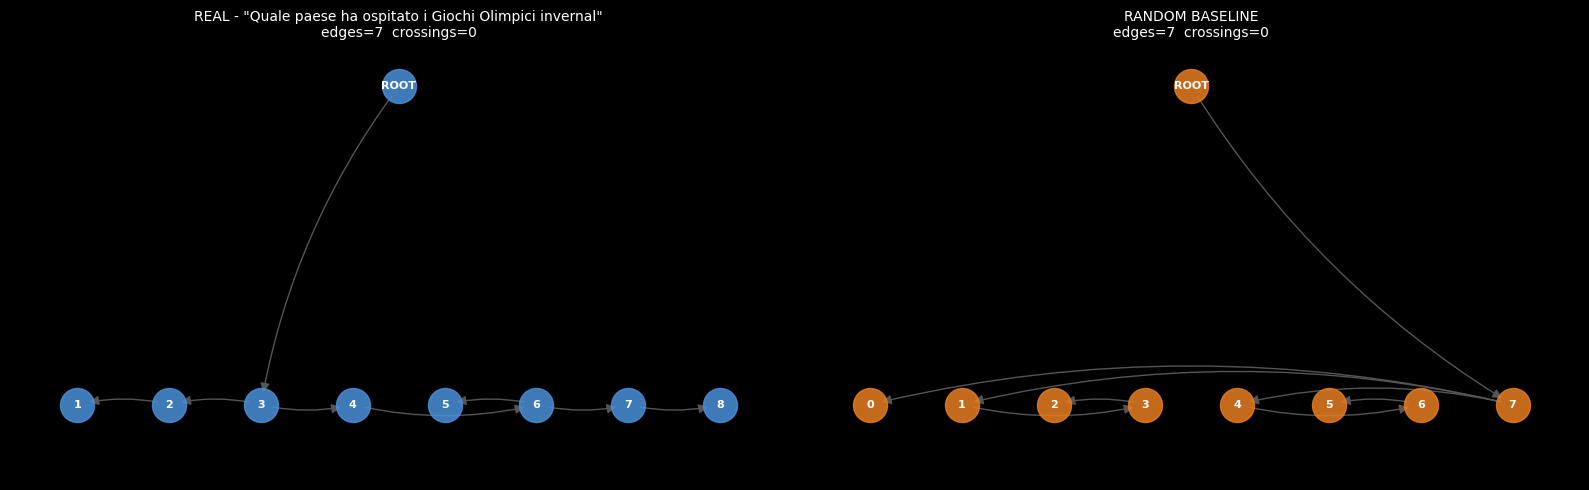

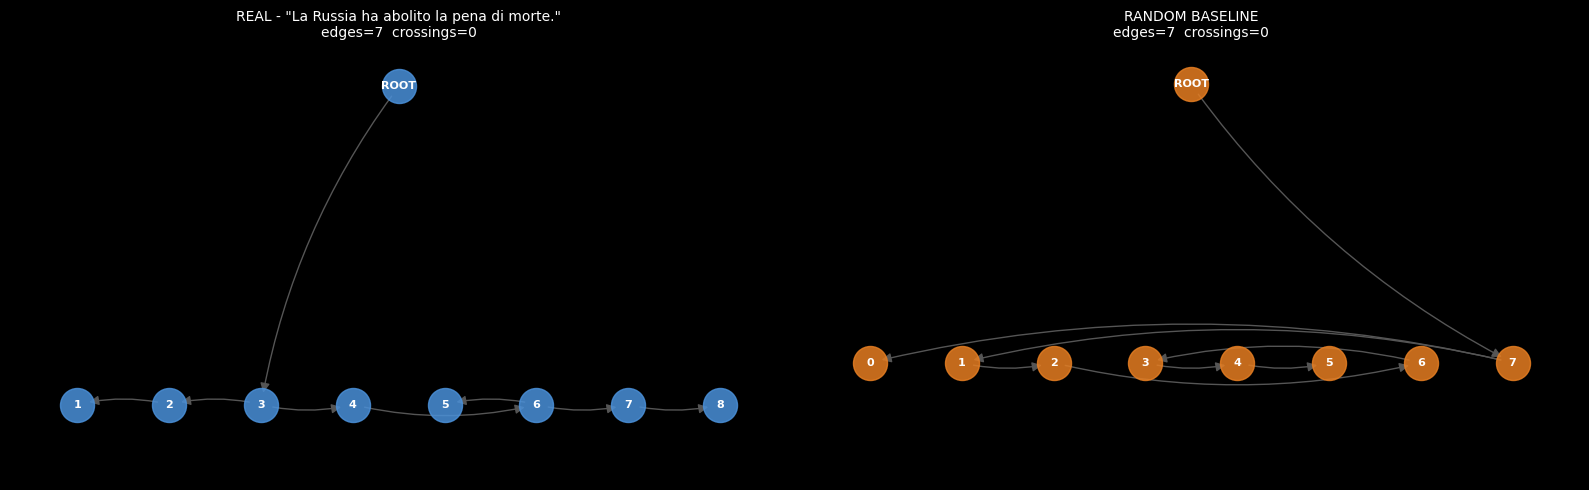

In [7]:
def compare_trees(rec: Dict, figsize: Tuple = (16, 5)):
    """Plot a real tree and its random baseline side by side."""
    real_tree = rec['tree']
    rand_tree = rec.get('random_tree')
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    def draw(ax, tree, title, abstract_root, color):
        non_root = sorted(n for n in tree.nodes if n != abstract_root)
        mid = (non_root[0] + non_root[-1]) / 2 if non_root else 0
        pos = {abstract_root: (mid, 1)}
        for n in non_root:
            pos[n] = (n, 0)
        labels = {abstract_root: 'ROOT'}
        for n in non_root:
            labels[n] = str(n)
        nx.draw_networkx_nodes(tree, pos, node_color=color,
                               node_size=600, alpha=0.85, ax=ax)
        nx.draw_networkx_labels(tree, pos, labels, font_size=8,
                                font_weight='bold', font_color='white', ax=ax)
        nx.draw_networkx_edges(tree, pos, edge_color='#555',
                               arrows=True, arrowsize=14,
                               connectionstyle='arc3,rad=0.12', ax=ax)
        ncross = count_crossings(tree, abstract_root)
        ax.set_title(title + "\nedges=" + str(len(tree.edges)-1) + "  crossings=" + str(ncross),
                     fontsize=10, pad=10)
        ax.axis('off')

    draw(axes[0], real_tree, 'REAL - "' + rec.get('text', '')[:50] + '"', 0, '#4A90D9')

    if rand_tree is not None:
        draw(axes[1], rand_tree, "RANDOM BASELINE", ABSTRACT_ROOT, '#E67E22')
    else:
        axes[1].text(0.5, 0.5, 'No random tree generated\n(no crossing match found)',
                     ha='center', va='center', fontsize=12, color='gray')
        axes[1].set_title('RANDOM BASELINE', fontsize=10)
        axes[1].axis('off')

    plt.tight_layout()
    plt.show()


if corpus_with_baselines:
    first_lang = list(corpus_with_baselines.keys())[0]
    for rec in corpus_with_baselines[first_lang][:3]:
        compare_trees(rec)


### 2.6 Baseline Generation Summary

Total real trees         : 15000
With random baseline     : 15000
Without random baseline  : 0

Crossings in real trees:
  0 crossings (projective): 13715
  1+ crossings            : 1285


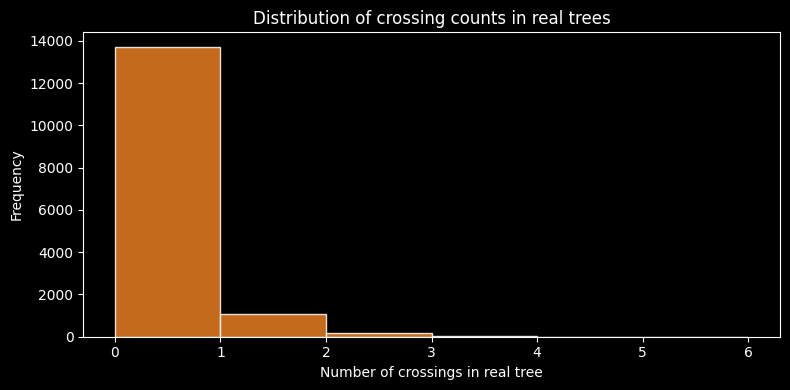

In [8]:
total_real = total_with = total_without = 0
crossing_counts = []

for lang, recs in corpus_with_baselines.items():
    has_rand = [r for r in recs if r.get('random_tree') is not None]
    no_rand  = [r for r in recs if r.get('random_tree') is None]
    total_real    += len(recs)
    total_with    += len(has_rand)
    total_without += len(no_rand)
    crossing_counts.extend([r['num_cross_real'] for r in has_rand])

print("Total real trees         :", total_real)
print("With random baseline     :", total_with)
print("Without random baseline  :", total_without)

if crossing_counts:
    print("\nCrossings in real trees:")
    print("  0 crossings (projective):", crossing_counts.count(0))
    print("  1+ crossings            :", sum(1 for c in crossing_counts if c > 0))

    plt.figure(figsize=(8, 4))
    plt.hist(crossing_counts,
             bins=range(0, max(crossing_counts) + 2),
             edgecolor='white', color='#E67E22', alpha=0.85)
    plt.xlabel('Number of crossings in real tree')
    plt.ylabel('Frequency')
    plt.title('Distribution of crossing counts in real trees')
    plt.tight_layout()
    plt.show()


## Step 3: Feature Extraction & Master Dataset

We extract an 8-parameter feature set for every real/random tree pair,
build a unified Pandas DataFrame, and export it to CSV for ML (Step 4).

| # | Feature | Description |
|---|---------|-------------|
| 1 | Max Arity | Highest out-degree of any node |
| 2 | Avg Arity | Mean out-degree |
| 3 | Max Depth | Longest root-to-leaf path |
| 4 | Graph Density | `nx.density()` |
| 5 | Avg ICM | Avg intervening heads per edge |
| 6 | Avg DLM | Avg linear distance per edge |
| 7 | Directionality | Fraction of left-to-right edges |
| 8 | Crossings | Non-projective edge count (constrained equal) |


### 3.0 Extract Features per Language

In [9]:
import numpy as np

language_features = {}

print("Extracting features for all valid tree pairs per language...")
for lang, recs in corpus_with_baselines.items():
    real_features = []
    rand_features = []
    for rec in recs:
        real_tree  = rec.get('tree')
        random_tree = rec.get('random_tree')
        if random_tree is not None:
            cross = rec.get('num_cross_real', 0)
            real_features.append(get_tree_features(real_tree,  root=0,            ncross=cross))
            rand_features.append(get_tree_features(random_tree, root=ABSTRACT_ROOT, ncross=cross))
    language_features[lang] = {
        'real':   np.array(real_features),
        'random': np.array(rand_features)
    }
    print("  [ok]", lang, ": extracted 8 features across", len(real_features), "sentence pairs")


Extracting features for all valid tree pairs per language...
  [ok] Italian : extracted 8 features across 1500 sentence pairs
  [ok] english : extracted 8 features across 1500 sentence pairs
  [ok] french : extracted 8 features across 1500 sentence pairs
  [ok] hindi : extracted 8 features across 1500 sentence pairs
  [ok] japanese : extracted 8 features across 1500 sentence pairs
  [ok] korean : extracted 8 features across 1500 sentence pairs
  [ok] latin : extracted 8 features across 1500 sentence pairs
  [ok] russian : extracted 8 features across 1500 sentence pairs
  [ok] spanish : extracted 8 features across 1500 sentence pairs
  [ok] turkish : extracted 8 features across 1500 sentence pairs


### 3.1 Build Master Features Dataset

In [10]:
import pandas as pd

rows = []
feature_names = ['Max_Arity','Avg_Arity','Max_Depth','Graph_Density',
                 'Avg_ICM','Avg_DLM','Directionality','Crossings']

for lang, data in language_features.items():
    for ftype, arr in [('Real', data['real']), ('Random', data['random'])]:
        for f in arr:
            row = {'Language': lang, 'Type': ftype}
            for name, val in zip(feature_names, f):
                row[name] = val
            rows.append(row)

df_master = pd.DataFrame(rows)

csv_path = 'Random_Data/Master_Features.csv'
os.makedirs('Random_Data', exist_ok=True)
df_master.to_csv(csv_path, index=False)
print("Master dataset:", len(df_master), "rows x", len(df_master.columns), "columns")
print("Saved to:", csv_path)
df_master.sample(5)


Master dataset: 30000 rows x 10 columns
Saved to: Random_Data/Master_Features.csv


,Language,Type,Max_Arity,Avg_Arity,Max_Depth,Graph_Density,Avg_ICM,Avg_DLM,Directionality,Crossings
5528,english,Random,4.0,0.857143,3.0,0.125000,1.333333,1.833333,0.166667,0.0
15977,korean,Real,2.0,0.750000,3.0,0.200000,1.333333,1.000000,0.333333,0.0
7532,french,Random,2.0,0.888889,7.0,0.100000,2.500000,2.375000,0.625000,0.0
3935,english,Real,2.0,0.800000,4.0,0.166667,1.000000,0.250000,1.000000,0.0
21482,russian,Real,3.0,0.909091,4.0,0.083333,1.100000,0.800000,0.600000,0.0


### 3.2 Global Comparative Visualisations

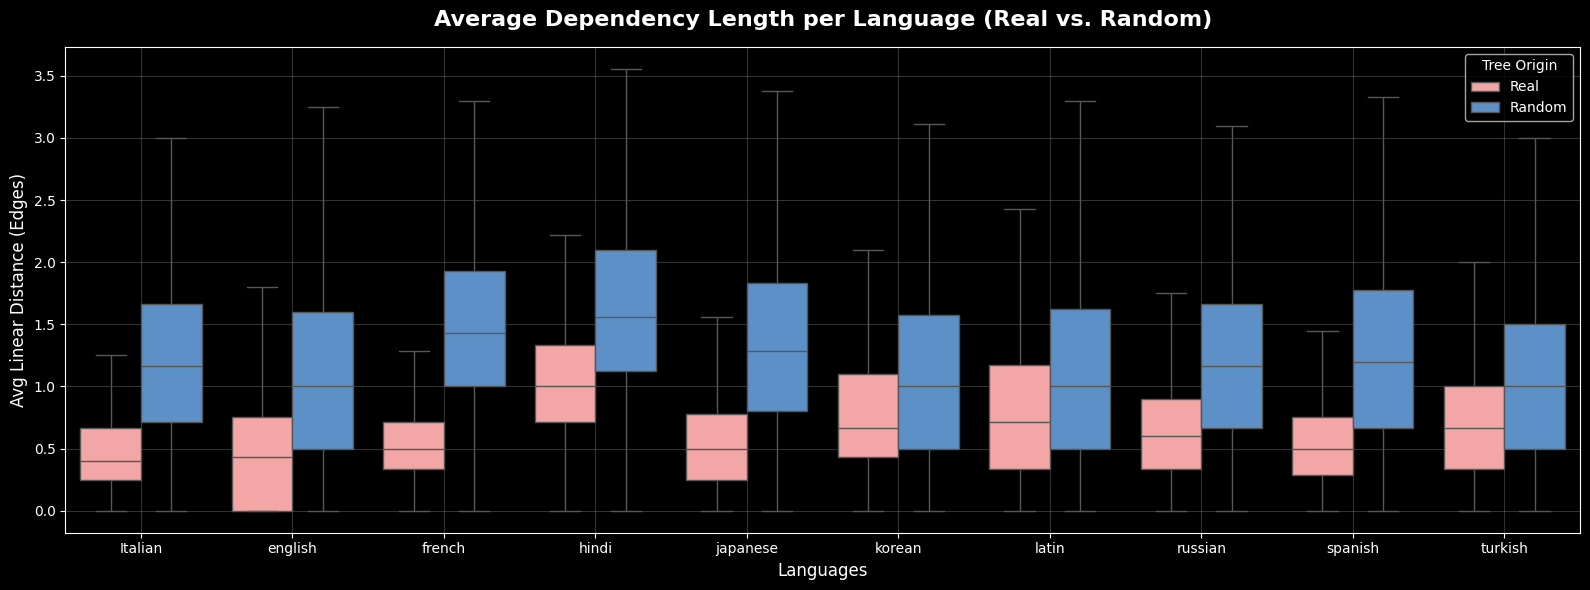

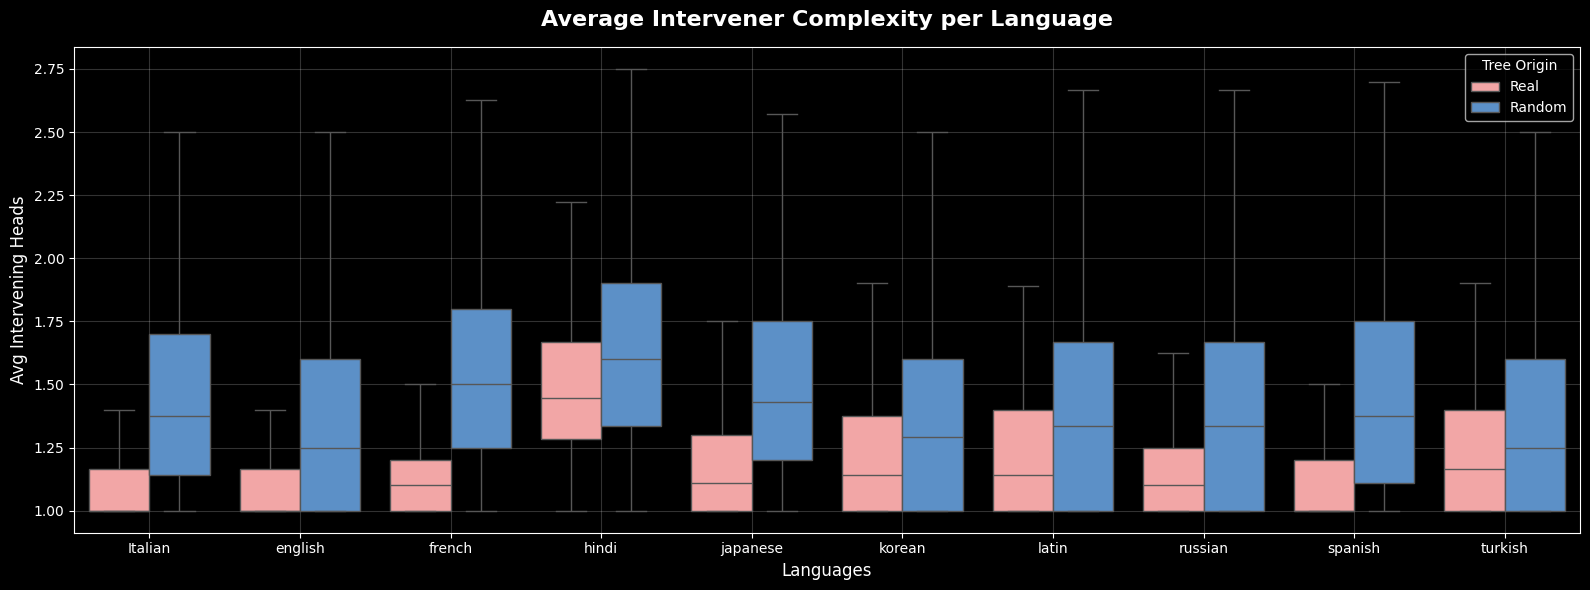

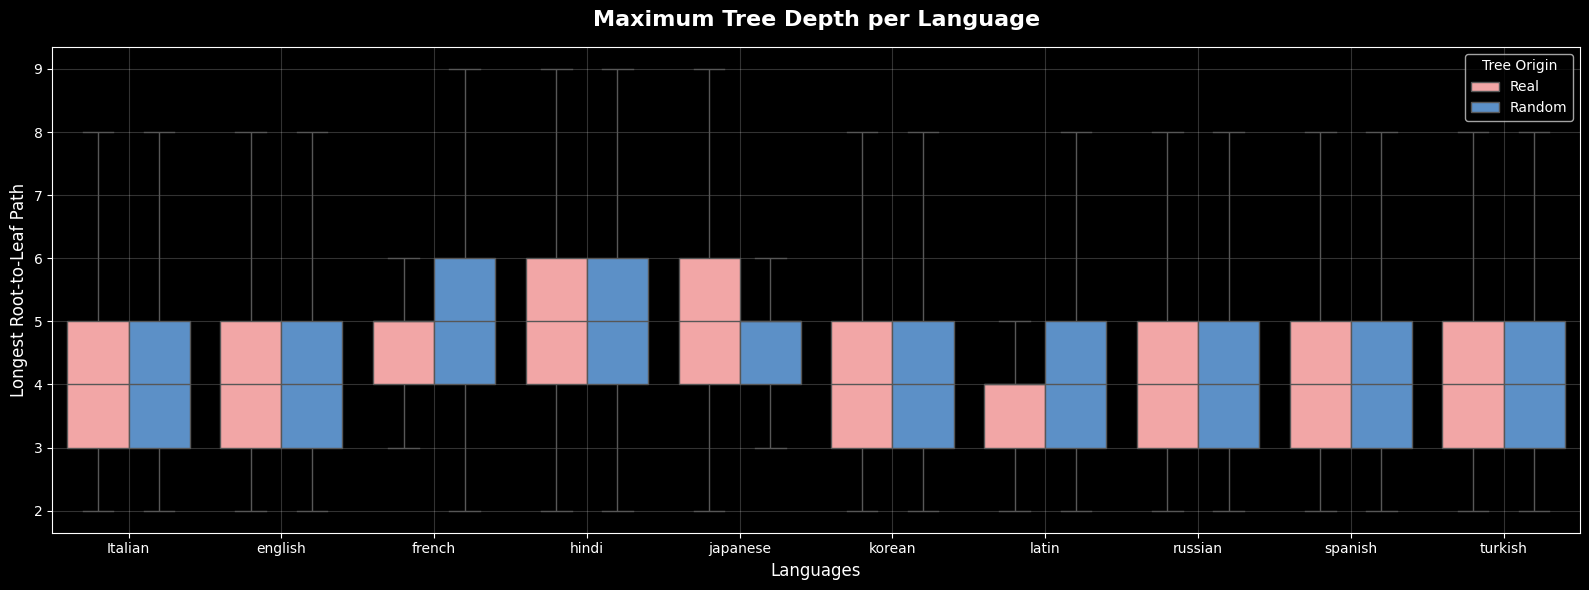

In [11]:
import seaborn as sns

plt.style.use('dark_background')

def plot_global_comparison(metric, title, ylabel):
    plt.figure(figsize=(16, 6))
    sns.boxplot(data=df_master, x='Language', y=metric, hue='Type',
                palette=['#FF9999', '#4A90D9'], showfliers=False)
    plt.title(title, fontsize=16, pad=15, weight='bold')
    plt.ylabel(ylabel, fontsize=12)
    plt.xlabel('Languages', fontsize=12)
    plt.grid(alpha=0.2)
    plt.legend(title='Tree Origin')
    plt.tight_layout()
    plt.show()
plot_global_comparison('Avg_DLM',
    'Average Dependency Length per Language (Real vs. Random)',
    'Avg Linear Distance (Edges)')

plot_global_comparison('Avg_ICM',
    'Average Intervener Complexity per Language',
    'Avg Intervening Heads')

plot_global_comparison('Max_Depth',
    'Maximum Tree Depth per Language',
    'Longest Root-to-Leaf Path')


### 3.3 Active Memory Burden Analysis (M(t) Waveforms)

Visualising the Active Memory Burden M(t) for real vs random trees across languages to test the hypothesis of human languages having lower waveform volatility.

== Loading Waveform Data ==


Mean_Avg  Mean_Std  Count
Language Type                             
Italian  Random    1.8800    1.1289   1500
         Real      1.2111    0.7155   1500
english  Random    1.6628    1.0352   1500
         Real      1.1925    0.7532   1500
french   Random    2.1880    1.2718   1500
         Real      1.3463    0.7546   1500
hindi    Random    2.3144    1.3246   1500
         Real      1.7940    0.9853   1500
japanese Random    2.0170    1.1917   1500
         Real      1.3410    0.7712   1500

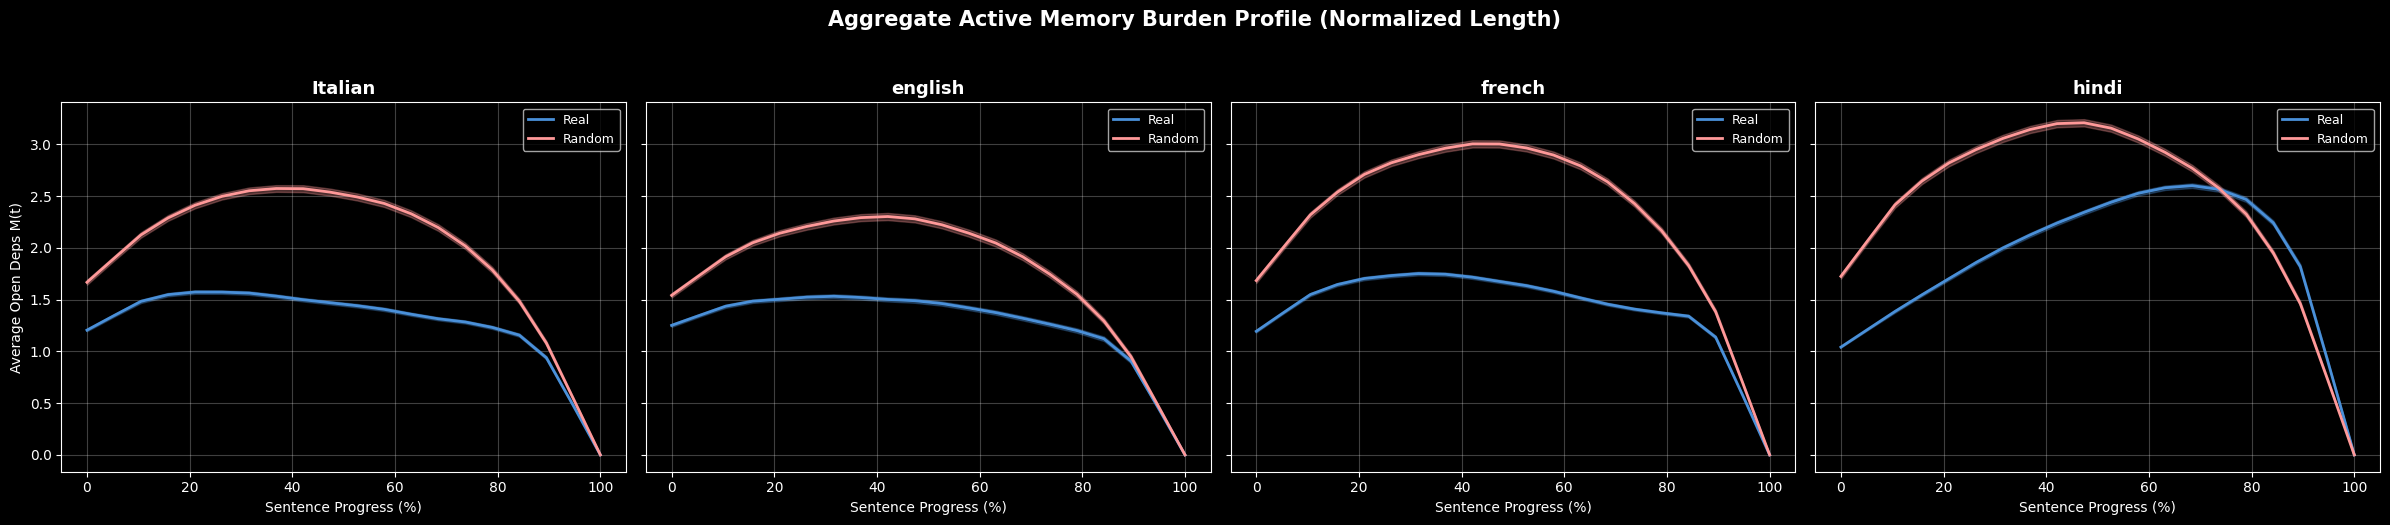

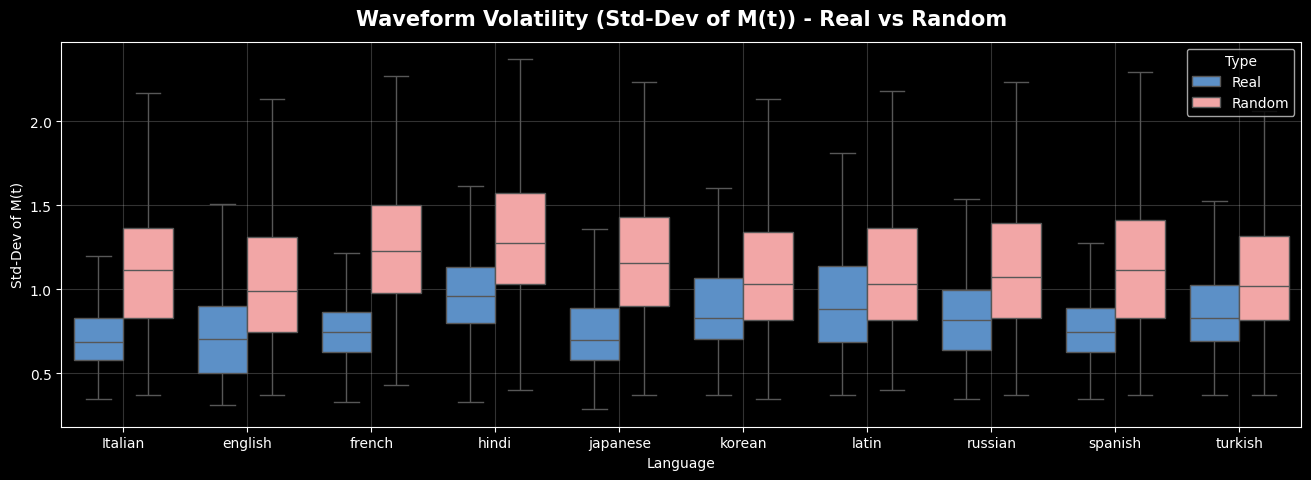

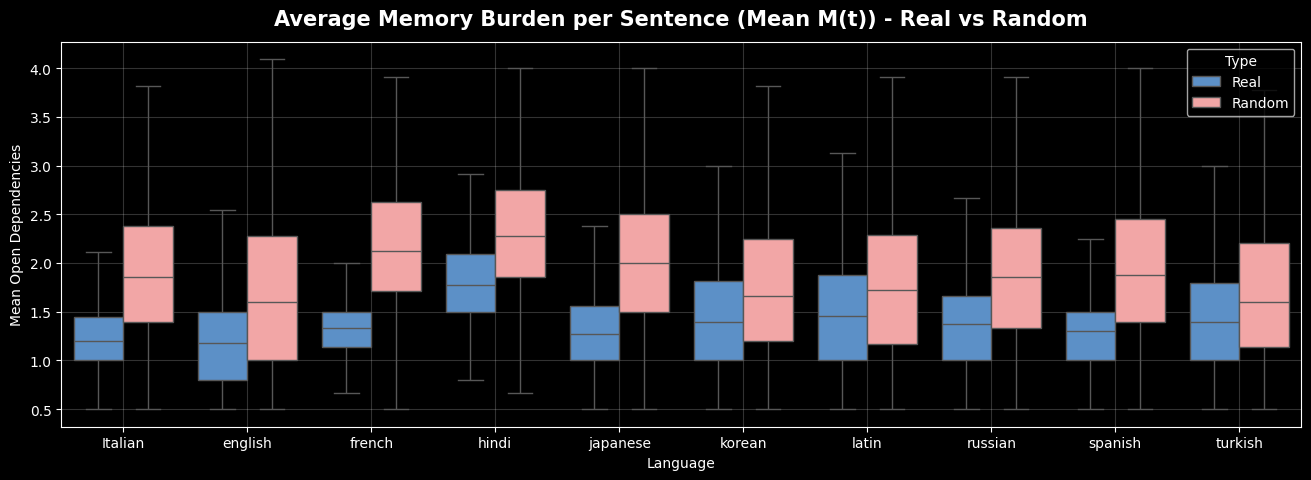

In [12]:
import sys
if 'src' not in sys.path:
    sys.path.append('src')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from data_processor import load_and_compute

plt.style.use("dark_background")

print("== Loading Waveform Data ==")
# We use load_and_compute from our new modular src/data_processor.py
df_waves = load_and_compute(n_bins=20)

# Summary table
summary = df_waves.groupby(["Language", "Type"]).agg(
    Mean_Avg=("Mean", "mean"), Mean_Std=("Std", "mean"), Count=("Length", "count")
).round(4)
display(summary.head(10))

# Plot 1: Interpolated Aggregate Profiles
def plot_aggregate_profiles(df, n_langs=3):
    langs = df["Language"].unique()[:n_langs]
    fig, axes = plt.subplots(1, len(langs), figsize=(6 * len(langs), 5), sharey=True)
    if len(langs) == 1: axes = [axes]
    
    x = np.linspace(0, 100, 20)
    for ax, lang in zip(axes, langs):
        sub = df[df["Language"] == lang]
        reals = np.vstack(sub[sub["Type"] == "Real"]["Interp_Waveform"].values)
        randoms = np.vstack(sub[sub["Type"] == "Random"]["Interp_Waveform"].values)
        
        real_mean, real_std = np.mean(reals, axis=0), np.std(reals, axis=0) / np.sqrt(len(reals))
        rand_mean, rand_std = np.mean(randoms, axis=0), np.std(randoms, axis=0) / np.sqrt(len(randoms))
        
        ax.plot(x, real_mean, color="#4A90D9", linewidth=2.0, label="Real")
        ax.fill_between(x, real_mean - real_std, real_mean + real_std, color="#4A90D9", alpha=0.3)
        ax.plot(x, rand_mean, color="#FF9999", linewidth=2.0, label="Random")
        ax.fill_between(x, rand_mean - rand_std, rand_mean + rand_std, color="#FF9999", alpha=0.3)
        
        ax.set_title(f"{lang}", fontsize=13, weight="bold")
        ax.set_xlabel("Sentence Progress (%)", fontsize=10)
        if ax == axes[0]: ax.set_ylabel("Average Open Deps M(t)", fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.25)
        
    fig.suptitle("Aggregate Active Memory Burden Profile (Normalized Length)", fontsize=15, weight="bold", y=1.04)
    fig.tight_layout()
    plt.show()

plot_aggregate_profiles(df_waves, n_langs=4)

# Plot 2: Volatility Comparison
fig, ax = plt.subplots(figsize=(16, 5))
sns.boxplot(data=df_waves, x="Language", y="Std", hue="Type", palette=["#4A90D9", "#FF9999"], showfliers=False, ax=ax)
ax.set_title("Waveform Volatility (Std-Dev of M(t)) - Real vs Random", fontsize=15, weight="bold", pad=12)
ax.set_ylabel("Std-Dev of M(t)")
ax.grid(alpha=0.2)
plt.show()

# Plot 3: Average Cognitive Workload (Mean M(t)) Comparison
fig, ax = plt.subplots(figsize=(16, 5))
sns.boxplot(data=df_waves, x="Language", y="Mean", hue="Type", palette=["#4A90D9", "#FF9999"], showfliers=False, ax=ax)
ax.set_title("Average Memory Burden per Sentence (Mean M(t)) - Real vs Random", fontsize=15, weight="bold", pad=12)
ax.set_ylabel("Mean Open Dependencies")
ax.grid(alpha=0.2)
plt.show()


### 3.4 Typological Analysis (SVO vs SOV)

Comparing word order effects on dependency structures and cognitive burden.
We focus entirely on **Real Trees** for this analysis since word order is a direct human grammar constraint.

**Typology Mapping:**
* **SVO (Head-Initial Subject-Verb-Object):** English, French, Italian, Spanish, Russian
* **SOV (Head-Final Subject-Object-Verb):** Hindi, Japanese, Korean, Turkish, Latin

C:\Users\tusha\AppData\Local\Temp\ipykernel_18888\540008364.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_typology, x="Typology", y="Directionality", palette=["#5da5da", "#faa43a"], showfliers=False, ax=axes[0])
C:\Users\tusha\AppData\Local\Temp\ipykernel_18888\540008364.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_typology, x="Typology", y="Avg_DLM", palette=["#5da5da", "#faa43a"], showfliers=False, ax=axes[1])
C:\Users\tusha\AppData\Local\Temp\ipykernel_18888\540008364.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

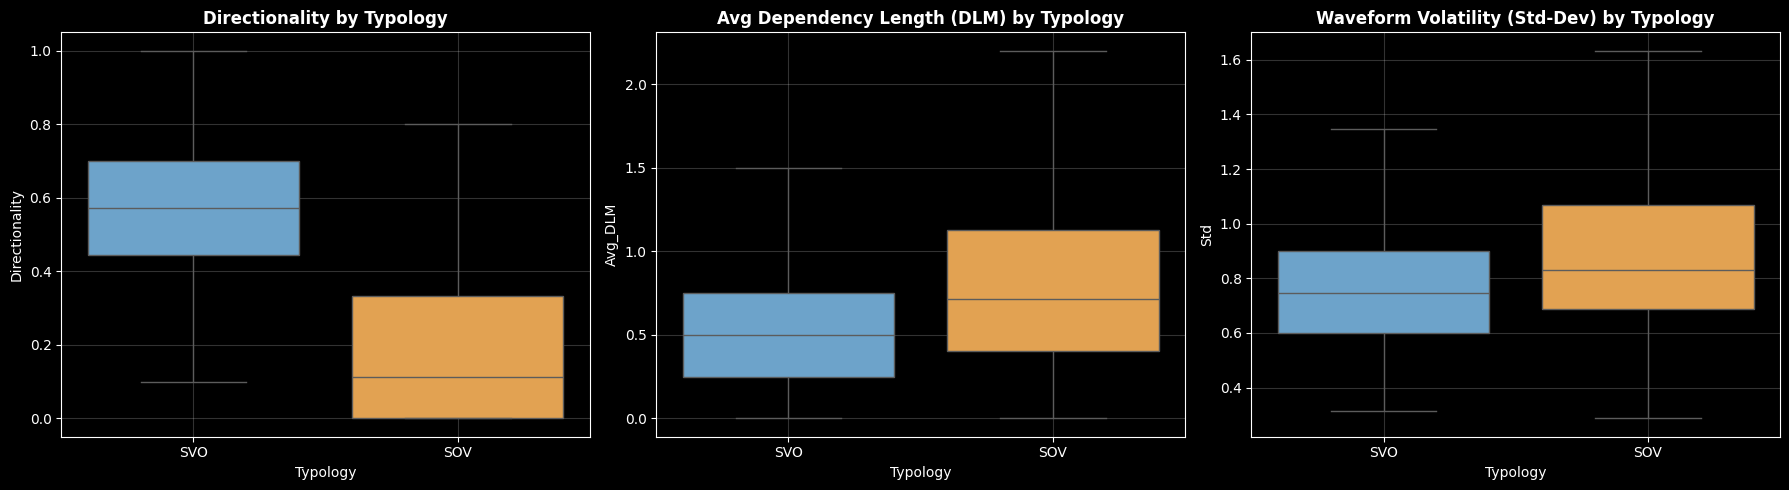

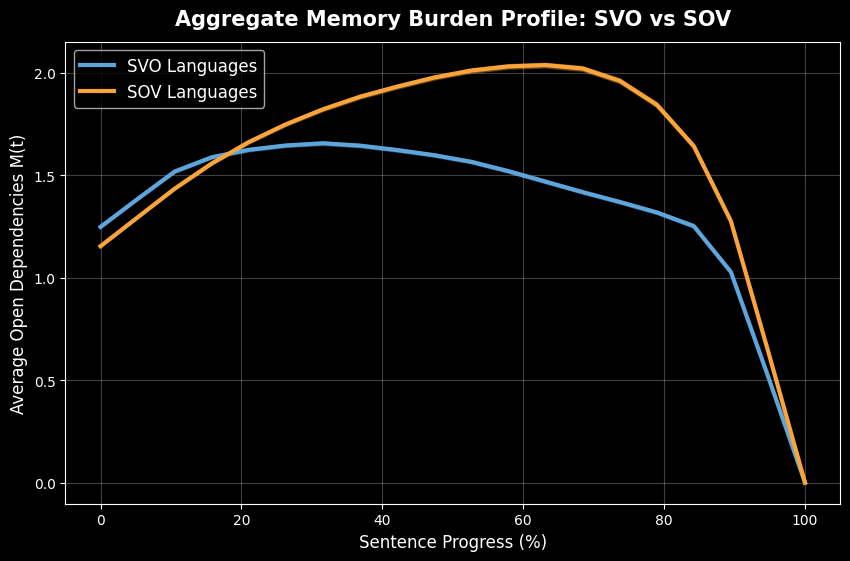

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load topological features
df_features = pd.read_csv("Random_Data/Master_Features.csv")

# 2. Merge Waveform features and topological features safely
# First, filter to Real trees only
df_real_waves = df_waves[df_waves["Type"] == "Real"].reset_index(drop=True)
df_real_features = df_features[df_features["Type"] == "Real"].reset_index(drop=True)

# Merge on index since ordering was guaranteed deterministic through generation
df_typology = pd.concat([df_real_features, df_real_waves[["Std", "Mean", "Interp_Waveform"]]], axis=1)

# 3. Apply Typology mappings
svo_langs = ["english", "french", "Italian", "spanish", "russian"]
sov_langs = ["hindi", "japanese", "korean", "turkish", "latin"]

def get_typology(lang):
    if lang in svo_langs: return "SVO"
    if lang in sov_langs: return "SOV"
    return "Other"

df_typology["Typology"] = df_typology["Language"].apply(get_typology)

# 4. Typology Comparison Boxplots (Topological and Temporal metrics)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df_typology, x="Typology", y="Directionality", palette=["#5da5da", "#faa43a"], showfliers=False, ax=axes[0])
axes[0].set_title("Directionality by Typology", weight='bold')

sns.boxplot(data=df_typology, x="Typology", y="Avg_DLM", palette=["#5da5da", "#faa43a"], showfliers=False, ax=axes[1])
axes[1].set_title("Avg Dependency Length (DLM) by Typology", weight='bold')

sns.boxplot(data=df_typology, x="Typology", y="Std", palette=["#5da5da", "#faa43a"], showfliers=False, ax=axes[2])
axes[2].set_title("Waveform Volatility (Std-Dev) by Typology", weight='bold')

for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()


# 5. Aggregate Waveform Profile for SVO vs SOV
fig, ax = plt.subplots(figsize=(10, 6))
x = np.linspace(0, 100, 20)

svo_data = np.vstack(df_typology[df_typology["Typology"] == "SVO"]["Interp_Waveform"].values)
sov_data = np.vstack(df_typology[df_typology["Typology"] == "SOV"]["Interp_Waveform"].values)

svo_mean, svo_std = np.mean(svo_data, axis=0), np.std(svo_data, axis=0) / np.sqrt(len(svo_data))
sov_mean, sov_std = np.mean(sov_data, axis=0), np.std(sov_data, axis=0) / np.sqrt(len(sov_data))

ax.plot(x, svo_mean, color="#5da5da", linewidth=3.0, label="SVO Languages")
ax.fill_between(x, svo_mean - svo_std, svo_mean + svo_std, color="#5da5da", alpha=0.3)

ax.plot(x, sov_mean, color="#faa43a", linewidth=3.0, label="SOV Languages")
ax.fill_between(x, sov_mean - sov_std, sov_mean + sov_std, color="#faa43a", alpha=0.3)

ax.set_title("Aggregate Memory Burden Profile: SVO vs SOV", fontsize=15, weight="bold", pad=12)
ax.set_xlabel("Sentence Progress (%)", fontsize=12)
ax.set_ylabel("Average Open Dependencies M(t)", fontsize=12)
ax.legend(fontsize=12)
ax.grid(alpha=0.25)
plt.show()


## Step 4: Machine Learning Pipeline
This section prepares the consolidated dataset and runs the ablation studies for:
1. **Task A**: Real vs. Random Tree Classification.
2. **Task B**: Typology Prediction (SOV vs. SVO) using Leave-One-Language-Out cross-validation.

### 4.1 Data Consolidation
We merge the topological features (`df_features`) with the dynamic memory waves (`df_waves`) using a strict internal index to ensure sentence alignment.


In [14]:
import pandas as pd
import sys, os

# 1. Reload our features and compute the waveforms
# (Ensure steps 3.0 and 3.3 in your notebook were run earlier in your session)
if 'df_features' not in locals():
    df_features = pd.read_csv("Random_Data/Master_Features.csv")
if 'df_waves' not in locals():
    from data_processor import load_and_compute
    df_waves = load_and_compute(n_bins=20) 

# 2. Import our new ML Engine from src/
sys.path.insert(0, os.path.abspath('src'))
import ml_engine
from importlib import reload
reload(ml_engine) # Syncs changes if we edit src/ml_engine.py

# 3. Perform the "Smart Merge"
# This aligns sentences by index and adds Target columns (is_real, Typology)
df_master_ml = ml_engine.prepare_dataset(df_features, df_waves)

# 4. Success Check
print("\nConsolidated ML Dataset Sample:")
display(df_master_ml.sample(5))


Preparing consolidated ML dataset...
  ✓ Success: Merged into 30000 samples with 21 columns.
  ✓ Targets created: 'is_real' and 'Typology'.

Consolidated ML Dataset Sample:


,Language,Type,Max_Arity,Avg_Arity,Max_Depth,Graph_Density,Avg_ICM,Avg_DLM,Directionality,Crossings,...,Std,Peak,Mean,Length,Rel_Peak_Pos,Peak_Mean_Ratio,Change_Rate,Skewness,is_real,Typology
7617,french,Random,3.0,0.909091,7.0,0.083333,1.7,1.400000,0.300000,0.0,...,1.336085,5,2.181818,11,0.272727,2.291667,0.818182,0.676181,0,SVO
14845,japanese,Random,3.0,0.800000,3.0,0.166667,1.0,0.750000,0.000000,0.0,...,1.019804,3,1.400000,5,0.600000,2.142857,1.000000,0.404796,0,SOV
17702,korean,Random,2.0,0.750000,3.0,0.200000,1.0,0.666667,0.333333,0.0,...,0.829156,2,1.250000,4,0.000000,1.600000,1.000000,-0.854563,0,SOV
1130,Italian,Real,2.0,0.833333,3.0,0.142857,1.0,0.200000,0.400000,0.0,...,0.577350,2,1.000000,6,0.500000,2.000000,0.500000,0.000000,1,SVO
15119,korean,Real,3.0,0.888889,5.0,0.100000,1.5,1.500000,0.125000,0.0,...,1.133115,4,2.222222,9,0.222222,1.800000,1.222222,-0.537175,1,SOV
